# Early Diabetes Risk Prediction System

SEML Assignment 1

Group 66

## Objective

To predict the likelihood of diabetes in patients using Machine Learning techniques based on clinical and demographic information.

## Dataset

Pima Indians Diabetes Dataset

## Technology Stack

- Python
- Pandas
- NumPy
- Scikit-Learn
- Streamlit
- Google Colab

In [40]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully")

Libraries imported successfully


In [41]:
# Step 2: Upload the diabetes dataset

from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


In [42]:
# Step 3: Read the CSV file into a DataFrame

df = pd.read_csv("diabetes.csv")

print("Dataset loaded successfully")
print(df.shape)

Dataset loaded successfully
(768, 9)


In [43]:
# Step 4: Display the first 10 records

df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [44]:
# Step 5: Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [45]:
# Step 7: Count invalid zero values

columns_to_check = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in columns_to_check:
    zero_count = (df[column] == 0).sum()
    print(f"{column}: {zero_count}")

Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


In [46]:
# Step 8: Percentage of invalid zero values

columns_to_check = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in columns_to_check:
    zero_count = (df[column] == 0).sum()
    percentage = (zero_count / len(df)) * 100
    print(f"{column}: {zero_count} ({percentage:.2f}%)")

Glucose: 5 (0.65%)
BloodPressure: 35 (4.56%)
SkinThickness: 227 (29.56%)
Insulin: 374 (48.70%)
BMI: 11 (1.43%)


In [47]:
# Step 9: Calculate median values

columns_to_check = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in columns_to_check:
    median_value = df[column].replace(0, np.nan).median()
    print(f"{column}: {median_value}")

Glucose: 117.0
BloodPressure: 72.0
SkinThickness: 29.0
Insulin: 125.0
BMI: 32.3


In [48]:
# Step 10: Replace invalid zero values with median values

columns_to_check = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in columns_to_check:
    median_value = df[column].replace(0, np.nan).median()
    df[column] = df[column].replace(0, median_value)

print("Invalid zero values replaced successfully")

Invalid zero values replaced successfully


In [49]:
# Step 11: Verify data cleaning

for column in columns_to_check:
    zero_count = (df[column] == 0).sum()
    print(f"{column}: {zero_count}")

Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


## Dataset Overview and Data Quality Assessment

The Pima Indians Diabetes Dataset was successfully loaded and inspected. The dataset contains 768 patient records and 9 attributes, including the target variable Outcome.

Initial data quality assessment indicated that no null values were present. However, several attributes contained medically unrealistic zero values that represent missing information.

The affected attributes were:

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

The percentage of invalid zero values ranged from 0.65% for Glucose to 48.70% for Insulin.

To preserve the dataset and avoid losing observations, median imputation was applied. Invalid zero values were replaced with the median value of the corresponding attribute.

A verification step confirmed that all invalid zero values were successfully removed from the dataset.

##Exploratory Data Analysis (EDA)

In [50]:
# Check class distribution

df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


In [51]:
# Display percentage distribution

outcome_percentage = df["Outcome"].value_counts(normalize=True) * 100

print(outcome_percentage)

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


### Observation: Distribution of Diabetes Outcome

The target variable *Outcome* represents whether a patient has diabetes.

The dataset contains:

- 500 non-diabetic patients (65.10%)
- 268 diabetic patients (34.90%)

The class distribution indicates a moderate imbalance, with non-diabetic cases occurring more frequently than diabetic cases. However, both classes are sufficiently represented, making the dataset suitable for supervised machine learning without requiring immediate class balancing techniques.

Understanding the target distribution is important because it influences model evaluation and helps determine whether additional preprocessing steps may be required later.

#### Relationship Between Glucose and Diabetes Outcome

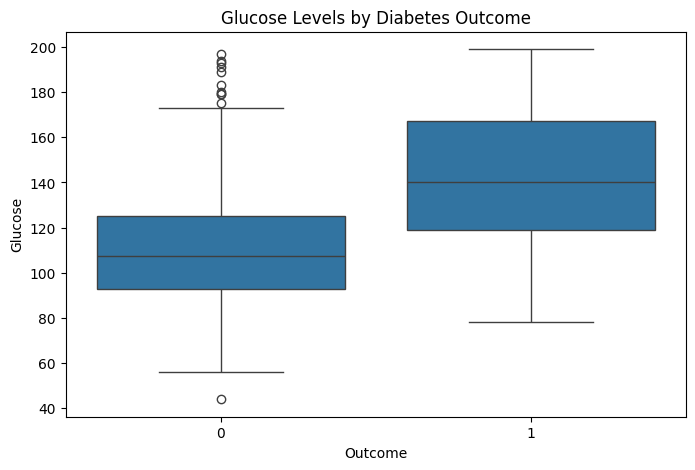

In [52]:
# Compare glucose levels across outcome categories

plt.figure(figsize=(8,5))

sns.boxplot(x="Outcome", y="Glucose", data=df)

plt.title("Glucose Levels by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose")

plt.show()

### Observation: Relationship Between Glucose and Diabetes Outcome

The boxplot shows a clear difference in glucose levels between diabetic and non-diabetic patients.

Patients with diabetes (Outcome = 1) generally exhibit significantly higher glucose levels than patients without diabetes (Outcome = 0).

The median glucose level for diabetic patients is substantially higher than that of non-diabetic patients. In addition, the overall glucose distribution for diabetic patients is shifted upward.

This observation suggests that glucose level is likely to be an important predictor of diabetes and may have strong influence on the machine learning model.

## Relationship Between BMI and Diabetes Outcome

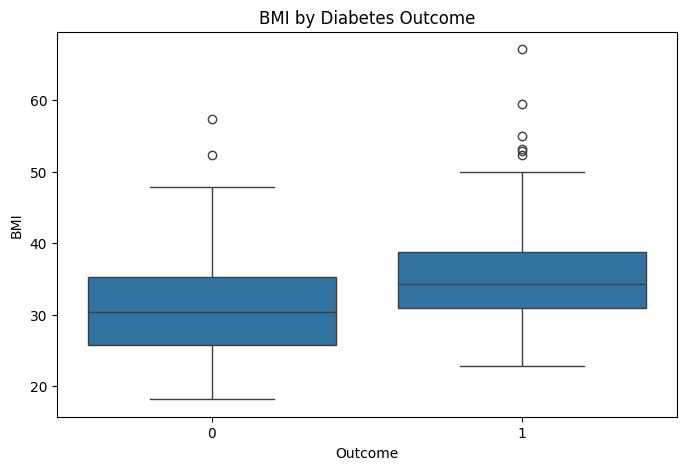

In [53]:
# Compare BMI across outcome categories

plt.figure(figsize=(8,5))

sns.boxplot(x="Outcome", y="BMI", data=df)

plt.title("BMI by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("BMI")

plt.show()

### Observation: Relationship Between BMI and Diabetes Outcome

The boxplot indicates that diabetic patients (Outcome = 1) generally have higher BMI values than non-diabetic patients (Outcome = 0).

The median BMI for diabetic patients is higher, and the distribution is shifted upward compared to the non-diabetic group. Several high-BMI outliers are also observed among diabetic patients.

Although there is some overlap between the two groups, the overall trend suggests that BMI is positively associated with diabetes risk.

This observation indicates that BMI is likely to be an important predictive feature for the machine learning model.

## Correlation Analysis

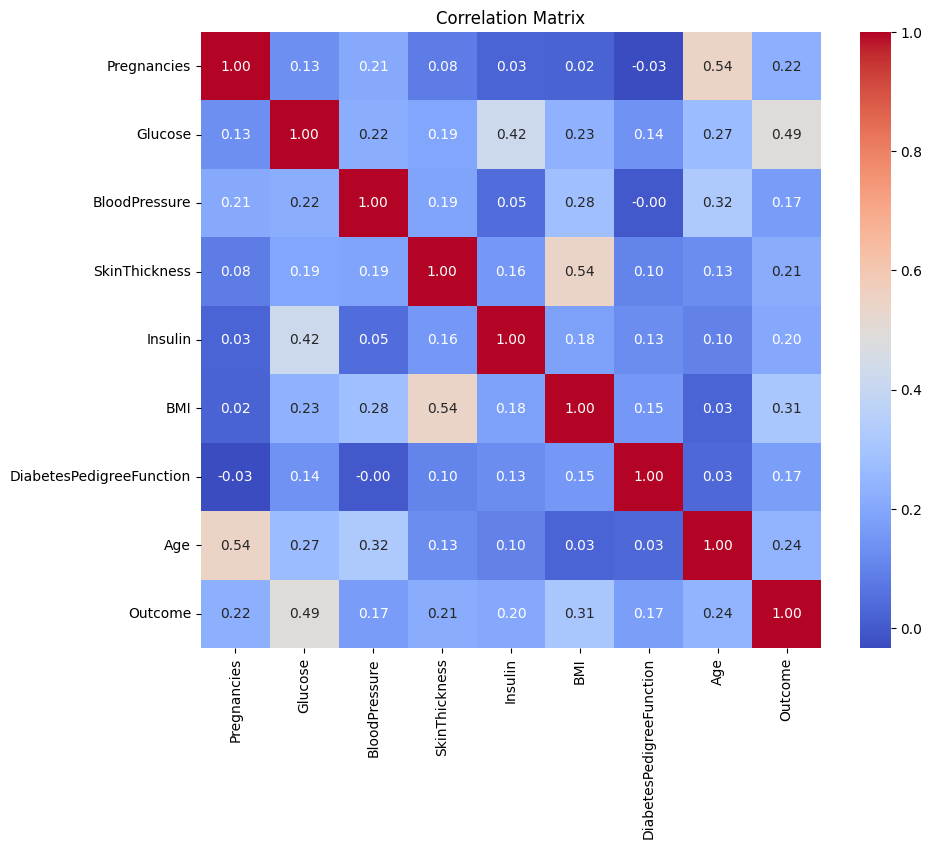

In [54]:
# Generate correlation matrix

correlation_matrix = df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Observation: Correlation Analysis

The correlation matrix was used to identify relationships between predictor variables and the target variable Outcome.

Among all features, Glucose exhibited the strongest positive correlation with diabetes outcome (0.49), indicating that higher glucose levels are strongly associated with diabetes.

BMI showed the second-highest correlation (0.31), followed by Age (0.24), Pregnancies (0.22), SkinThickness (0.21), and Insulin (0.20).

The correlation analysis confirms earlier exploratory findings that glucose level and BMI are important indicators of diabetes risk and are likely to contribute significantly to model performance.

No predictor demonstrated extremely high correlation with the target variable, suggesting that multiple features may collectively contribute to accurate prediction.

## Feature Scaling and Data Preparation for Model Training

## Feature Preparation and Train-Test Split

Before training a machine learning model, the dataset must be separated into predictor variables and the target variable.

The predictor variables represent patient characteristics and clinical measurements, while the target variable indicates whether the patient has diabetes.

The dataset is then divided into training and testing subsets. The training dataset is used to build the model, while the testing dataset is used to evaluate its performance on unseen data.

In [55]:
# Create predictor variables (X) and target variable (y)

X = df.drop("Outcome", axis=1)

y = df["Outcome"]

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

Feature matrix shape: (768, 8)
Target variable shape: (768,)


In [56]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (614, 8)
Testing Features : (154, 8)
Training Labels  : (614,)
Testing Labels   : (154,)


### Observation

The dataset was divided into training and testing subsets using an 80:20 ratio.

The training dataset will be used to build the machine learning model, while the testing dataset will be reserved for evaluating predictive performance on previously unseen observations.

This separation helps assess the model's ability to generalize beyond the training data.

In [57]:
# Standardize feature values

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully")

Feature scaling completed successfully


### Feature Scaling

The predictor variables contain values measured on different scales. For example, glucose levels, age, BMI, and insulin values have very different numeric ranges.

Standardization was applied so that each feature contributes proportionately during model training.

Feature scaling is particularly important for algorithms that are sensitive to feature magnitude and distance calculations.

## Model Development

The prepared dataset is now used to train machine learning models for diabetes prediction.

The objective is to learn patterns from the training dataset and evaluate predictive performance on previously unseen test data.

The first model selected for this study is Logistic Regression, which is widely used for binary classification problems and provides a strong baseline for comparison with more complex models.

In [58]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [59]:
# Train Logistic Regression model

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [60]:
# Generate predictions

y_pred_log = log_model.predict(X_test_scaled)

print("Predictions generated successfully")

Predictions generated successfully


In [61]:
# Calculate accuracy

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", round(log_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 75.32 %


### Observation: Logistic Regression Performance

A Logistic Regression model was trained using the standardized training dataset and evaluated on the testing dataset.

The model achieved an accuracy of 75.32% on previously unseen test data.

This result indicates that the model is capable of identifying diabetes-related patterns within the dataset and provides a strong baseline for further model comparison.

The achieved accuracy satisfies the minimum performance objective established for the project and demonstrates the feasibility of machine learning-based diabetes risk prediction.

In [62]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred_log)

print(cm)

[[82 17]
 [21 34]]


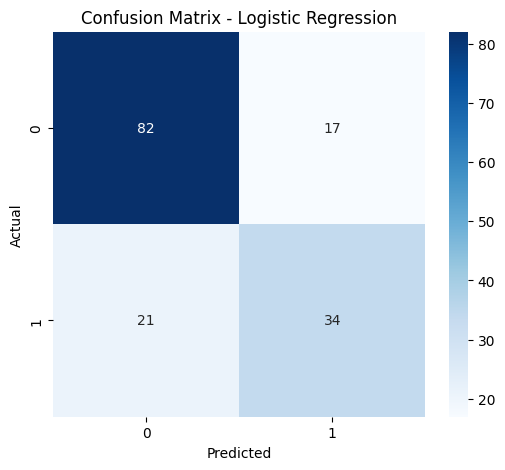

In [63]:
# Visualize confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation: Confusion Matrix Analysis

The confusion matrix provides a detailed view of model predictions beyond overall accuracy.

The Logistic Regression model correctly identified:

- 82 non-diabetic patients (True Negatives)
- 34 diabetic patients (True Positives)

The model incorrectly classified:

- 17 non-diabetic patients as diabetic (False Positives)
- 21 diabetic patients as non-diabetic (False Negatives)

From a healthcare perspective, false negatives are particularly important because they represent diabetic patients who were not identified by the model. Although the model achieved satisfactory overall accuracy, reducing false negatives remains an important consideration for future model improvements.

In [64]:
# Generate classification report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



### Observation: Classification Report Analysis

The Logistic Regression model achieved an overall accuracy of 75.32%.

For non-diabetic patients, the model achieved a precision of 80% and a recall of 83%, indicating strong performance in identifying healthy individuals.

For diabetic patients, the model achieved a precision of 67% and a recall of 62%. While the model is able to detect a significant proportion of diabetic cases, some diabetic patients remain undetected.

The weighted F1-score of 75% indicates a balanced overall performance and confirms that Logistic Regression provides a suitable baseline model for diabetes prediction.

Future model improvements should focus on increasing recall for diabetic patients in order to reduce false negative predictions.

## Model Comparison

In [65]:
# Import Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

In [66]:
# Train Decision Tree model

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train_scaled, y_train)

print("Decision Tree model trained successfully")

Decision Tree model trained successfully


In [67]:
# Generate predictions

y_pred_dt = dt_model.predict(X_test_scaled)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 72.73 %
Confusion Matrix
[[70 29]
 [13 42]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.71      0.77        99
           1       0.59      0.76      0.67        55

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.75      0.73      0.73       154



### Observation: Decision Tree Performance

A Decision Tree classifier was trained and evaluated using the same training and testing datasets.

The model achieved an accuracy of 72.73%, which is lower than the Logistic Regression model accuracy of 75.32%.

Although Decision Trees provide good interpretability and can model non-linear relationships, the current model did not outperform Logistic Regression on this dataset.

Based on accuracy alone, Logistic Regression remains the better-performing model at this stage of the analysis.

## Random Forest Model

In [68]:
# Import Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

In [69]:
# Train Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [70]:
# Generate predictions

y_pred_rf = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Random Forest Accuracy: 73.38 %
Confusion Matrix
[[70 29]
 [13 42]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.71      0.77        99
           1       0.59      0.76      0.67        55

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.75      0.73      0.73       154



### Observation: Random Forest Performance

A Random Forest classifier consisting of 100 decision trees was trained and evaluated on the diabetes dataset.

The model achieved an accuracy of 73.38%, which was higher than the Decision Tree model but lower than the Logistic Regression model.

Although Random Forest reduces overfitting compared to a single Decision Tree, it did not outperform Logistic Regression on this dataset.

This result suggests that the underlying relationships within the dataset can be effectively captured by the simpler Logistic Regression model.

#Support Vector Machine (SVM) Model

In [71]:
# Import SVM

from sklearn.svm import SVC

In [72]:
#Train SVM Model

svm_model = SVC(kernel='rbf', probability=True, random_state=42)

svm_model.fit(X_train_scaled, y_train)

print("Support Vector Machine (SVM) Model trained successfully")

Support Vector Machine (SVM) Model trained successfully


In [73]:
# Generate predictions

y_pred_svm = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", round(svm_accuracy * 100, 2), "%")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 74.68 %
[[83 16]
 [23 32]]
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        99
           1       0.67      0.58      0.62        55

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



#Observation :Support Vector Machine (SVM) Model

A Support Vector Machine (SVM) classifier was trained and evaluated on the diabetes dataset.

The model achieved an accuracy of 74.68%, which was slightly lower than the Logistic Regression model but higher than the Random Forest, Decision Tree, and K-Nearest Neighbors models.

The SVM algorithm was able to effectively identify patterns within the patient health data and produced competitive classification performance.

Although SVM is well suited for binary classification problems, it did not outperform Logistic Regression on this dataset.

This result suggests that while SVM is a strong predictive model for diabetes classification, the simpler Logistic Regression model was able to capture the underlying relationships in the dataset more effectively.

#K-Nearest Neighbors (KNN)

In [74]:
#Import KNN model

from sklearn.neighbors import KNeighborsClassifier

In [75]:
#Train KNN Model

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [76]:
#Generate Predictions

y_pred_knn = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", round(knn_accuracy * 100, 2), "%")
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 72.08 %
[[74 25]
 [18 37]]
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        99
           1       0.60      0.67      0.63        55

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154



#Observation :K- Nearest Neighbour (KNN) Model

A K-Nearest Neighbors (KNN) classifier with K = 5 was trained and evaluated on the diabetes dataset.

The model achieved an accuracy of 72.08%, which was lower than the Logistic Regression, Support Vector Machine, Random Forest, and Decision Tree models.

The KNN algorithm classified patients based on similarity to neighboring observations within the feature space.

Although feature scaling improved the effectiveness of distance calculations, the model did not achieve the same level of performance as the other classification algorithms.

This result suggests that KNN was less effective in capturing the underlying patterns within the diabetes dataset and was not selected as the final model for deployment.

## Model Comparison and Selection

In [77]:
# Compare model accuracies

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine (SVM)",
        "K-Nearest Neighbors (KNN)"
    ],
    "Accuracy (%)": [
        round(log_accuracy * 100, 2),
        round(dt_accuracy * 100, 2),
        round(rf_accuracy * 100, 2),
        round(svm_accuracy * 100, 2),
        round(knn_accuracy * 100, 2)
    ]
})

comparison_df.sort_values(
    by="Accuracy (%)",
    ascending=False
)

,Model,Accuracy (%)
0,Logistic Regression,75.32
3,Support Vector Machine (SVM),74.68
2,Random Forest,73.38
1,Decision Tree,72.73
4,K-Nearest Neighbors (KNN),72.08


## Final Model Selection

Five  machine learning algorithms were evaluated for diabetes prediction using the prepared dataset.

The models achieved the following accuracies:

| Model | Accuracy (%) |
|---------|----------|
| Logistic Regression | 75.32 |
| Support Vector Machine (SVM) | 74.68 |
| Random Forest | 73.38 |
| Decision Tree | 72.73 |
| K-Nearest Neighbours (KNN) | 72.08 |

Among the evaluated models, Logistic Regression achieved the highest predictive accuracy of 75.32%.

Although more complex algorithms such as Random Forest and Support Vector Machine were evaluated, Logistic Regression provided the best overall performance on the diabetes dataset.

The results suggest that the relationships between the input features and the target variable can be effectively captured using a linear classification model.

In addition to achieving the highest accuracy, Logistic Regression offers simplicity, interpretability, and lower computational complexity, making it well suited for healthcare decision-support applications.

Based on the evaluation results, Logistic Regression was selected as the final model for diabetes risk prediction and deployment.

## Conclusion

The objective of this project was to develop a machine learning solution capable of predicting diabetes risk using clinical and demographic patient data.

The Pima Indians Diabetes Dataset was analyzed, cleaned, and prepared for model development. Exploratory Data Analysis identified Glucose and BMI as important indicators of diabetes risk, while correlation analysis confirmed Glucose as the strongest predictor among the available features.

Five machine learning models were developed and evaluated, including Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (SVM), and K-Nearest Neighbors (KNN).

Model performance was assessed using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix analysis. Logistic Regression achieved the highest accuracy of 75.32% and was selected as the final model for deployment.

The results demonstrate that machine learning can effectively support early diabetes risk prediction and provide valuable decision-support capabilities for healthcare professionals.

## Future Enhancements

Several enhancements can be considered to improve the solution in future iterations:

1. Collect additional healthcare attributes to improve predictive performance.

2. Apply advanced feature engineering techniques and feature selection methods.

3. Explore additional machine learning algorithms such as XGBoost, Gradient Boosting, and Neural Networks.

4. Perform hyperparameter tuning to optimize model performance.

5. Address class imbalance using techniques such as SMOTE and oversampling.

6. Deploy the selected model through a Streamlit-based web application to enable real-time diabetes risk prediction.

7. Integrate the solution with electronic health record systems to support clinical decision-making.

In [78]:
import joblib

joblib.dump(log_model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Files saved successfully")

Files saved successfully
